### Setup — libraries and file

In [3]:
# Run this first (pip install once if needed)
# !pip install pandas numpy matplotlib seaborn openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   # use matplotlib for plots
plt.rcParams.update({'figure.max_open_warning': 0})
sns.set(style="whitegrid")

#csv_url = "https://raw.githubusercontent.com/erikaduarte/Netflix-Dataset/main/netflix_titles.csv"
df = pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### Data cleaning & engineering

In [4]:
# 1. Basic overview
print(df.shape)
df.info()
df.isna().sum()

# 2. Drop duplicate title+release_year
df = df.drop_duplicates(subset=['title', 'release_year'])

# 3. Trim whitespace
for col in ['type','rating','country','listed_in','duration']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# 4. Parse date_added (optional)
if 'date_added' in df.columns:
    df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# 5. Split multi-value fields into rows: genres (listed_in) and countries
#    This is critical: genres like "Dramas, International Movies" should be counted separately.
df_genres = df.copy()
df_genres['listed_in'] = df_genres['listed_in'].fillna('')
df_genres = df_genres.assign(listed_in = df_genres['listed_in'].str.split(','))
df_genres = df_genres.explode('listed_in')
df_genres['listed_in'] = df_genres['listed_in'].str.strip()

# Split country (optional)
df_genres['country'] = df_genres['country'].fillna('')
df_genres = df_genres.assign(country = df_genres['country'].str.split(','))
df_genres = df_genres.explode('country')
df_genres['country'] = df_genres['country'].str.strip()

# 6. Make numeric duration in minutes:
# duration has forms like "90 min" or "1 Season" — we'll extract numbers, and keep movies only for duration analysis if needed
def extract_minutes(x):
    if pd.isna(x): return np.nan
    x = str(x)
    # prefer numeric before first space if 'min'
    if 'min' in x:
        try:
            return int(x.split()[0])
        except:
            return np.nan
    # seasons -> treat as NaN or map to approx episodes*45 (optional)
    return np.nan

df_genres['duration_min'] = df_genres['duration'].apply(extract_minutes)

# 7. Create helpful categorical columns
df_genres['is_movie'] = (df_genres['type'].str.lower() == 'movie')
df_genres['release_decade'] = (df_genres['release_year'] // 10) * 10


(8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


### Prep helper functions (plot saving + top-N selection)

In [6]:
def savefig(fname):
    plt.tight_layout()
    plt.savefig(fname, dpi=300)
    print("Saved", fname)

def top_n(df, col, n=10):
    counts = df[col].value_counts().nlargest(n)
    return counts

# Example: top 12 genres
print(top_n(df_genres, 'listed_in', 12))


International Movies        3513
Dramas                      3202
Comedies                    1981
International TV Shows      1465
Action & Adventure          1182
Documentaries               1118
Independent Movies          1040
TV Dramas                    852
Children & Family Movies     845
Thrillers                    806
Romantic Movies              722
TV Comedies                  630
Name: listed_in, dtype: int64


### Simple vertical bar chart: Count of titles by Genre

Saved chart1_genre_counts_bar.png


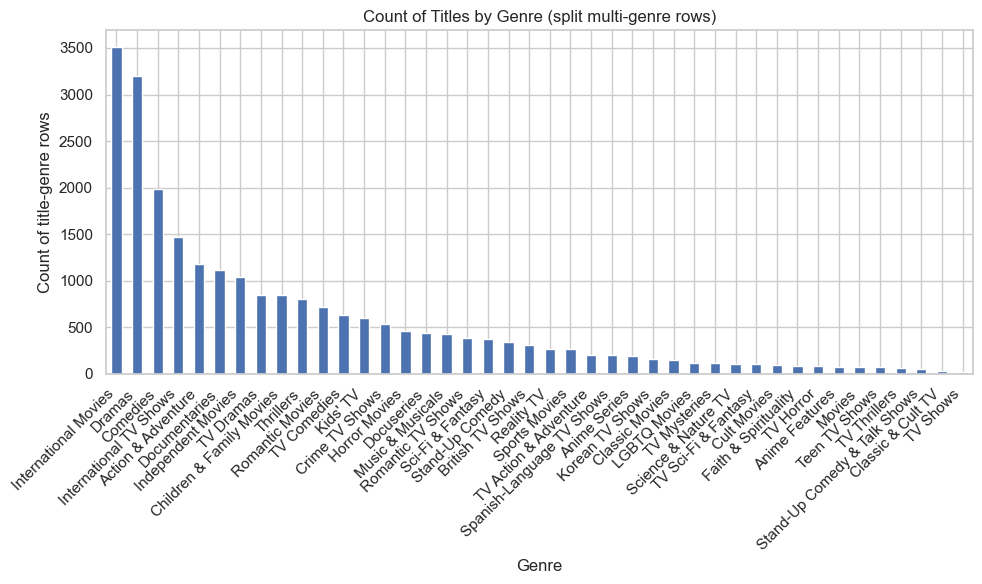

In [7]:
genre_counts = df_genres['listed_in'].value_counts().sort_values(ascending=False)
plt.figure(figsize=(10,6))
genre_counts.plot.bar()
plt.title('Count of Titles by Genre (split multi-genre rows)')
plt.ylabel('Count of title-genre rows')
plt.xlabel('Genre')
plt.xticks(rotation=45, ha='right')
savefig("chart1_genre_counts_bar.png")
plt.show()

### Horizontal bar chart (Top N): Top 10 Countries by Title Count

Saved chart2_top10_countries.png


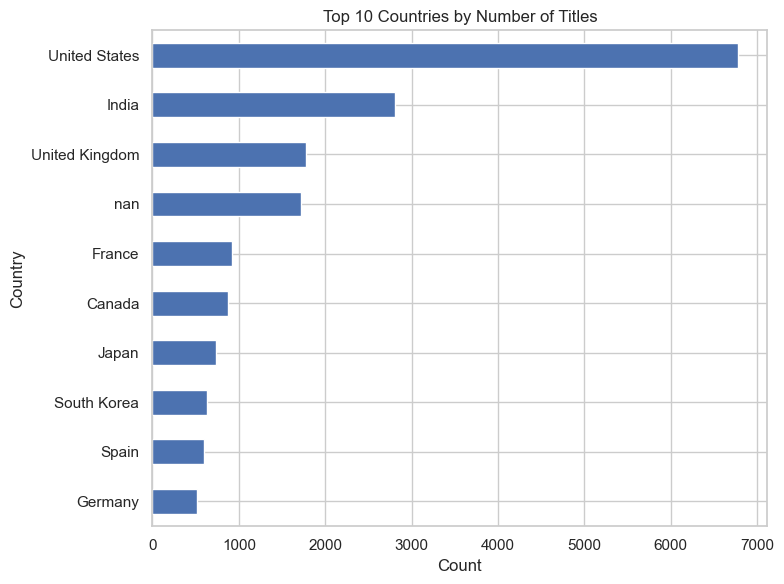

In [8]:
country_counts = df_genres['country'].replace('', np.nan).dropna().value_counts()
top10 = country_counts.nlargest(10)
plt.figure(figsize=(8,6))
top10.sort_values().plot.barh()   # plot smaller -> bigger vertically
plt.title('Top 10 Countries by Number of Titles')
plt.xlabel('Count')
plt.ylabel('Country')
savefig("chart2_top10_countries.png")
plt.show()

### Stacked bar chart: Rating breakdown by Type (Movie vs TV Show)

Saved chart3_stacked_rating_type.png


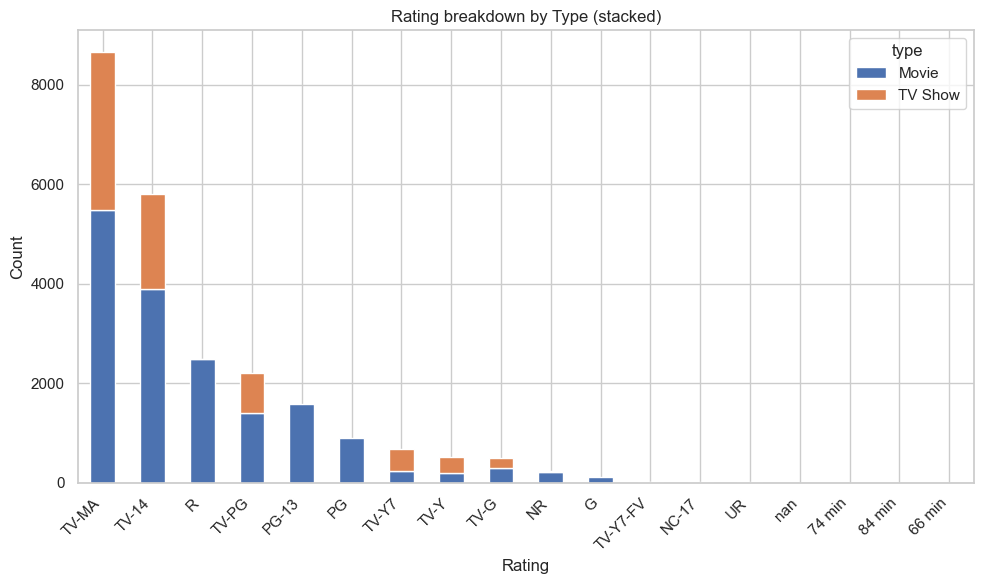

In [9]:
stack_df = df_genres.groupby(['rating','type']).size().unstack(fill_value=0)
stack_df = stack_df.loc[stack_df.sum(axis=1).sort_values(ascending=False).index]  # sort by total
stack_df.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Rating breakdown by Type (stacked)')
plt.ylabel('Count')
plt.xlabel('Rating')
plt.xticks(rotation=45, ha='right')
savefig("chart3_stacked_rating_type.png")
plt.show()

### 100% Stacked bar chart: Proportion Movie vs TV per top genres

Saved chart4_100pct_genre_type.png


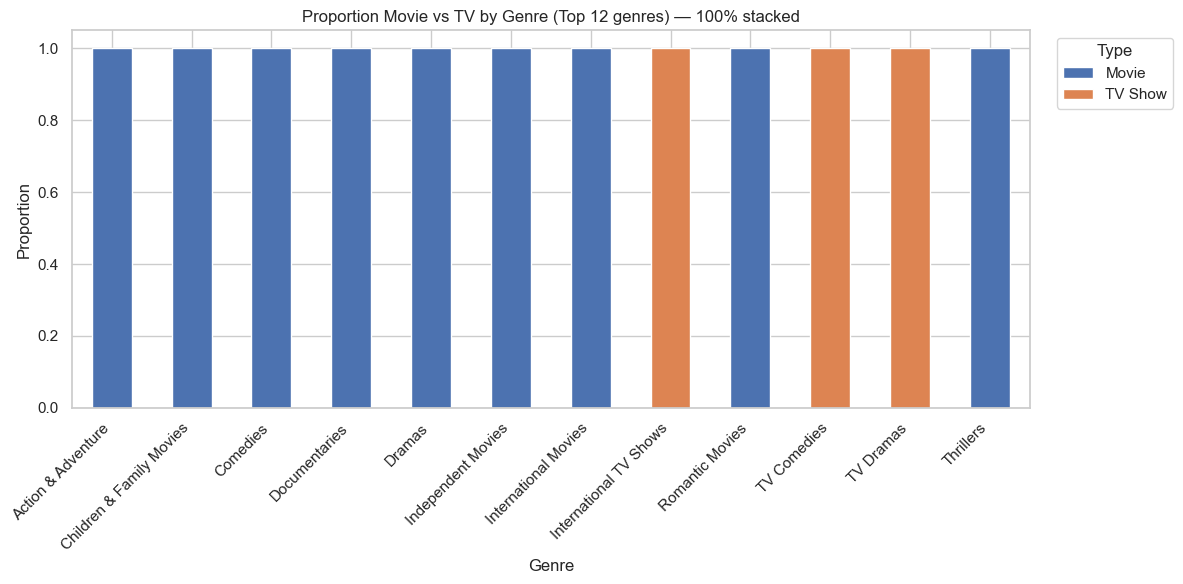

In [10]:
top_genres = df_genres['listed_in'].value_counts().nlargest(12).index
gdf = df_genres[df_genres['listed_in'].isin(top_genres)]
prop = gdf.groupby(['listed_in','type']).size().unstack(fill_value=0)
prop_pct = prop.div(prop.sum(axis=1), axis=0)

prop_pct.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Proportion Movie vs TV by Genre (Top 12 genres) — 100% stacked')
plt.ylabel('Proportion')
plt.xlabel('Genre')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Type', bbox_to_anchor=(1.02, 1))
savefig("chart4_100pct_genre_type.png")
plt.show()

### Bar Chart of Releases per Decade

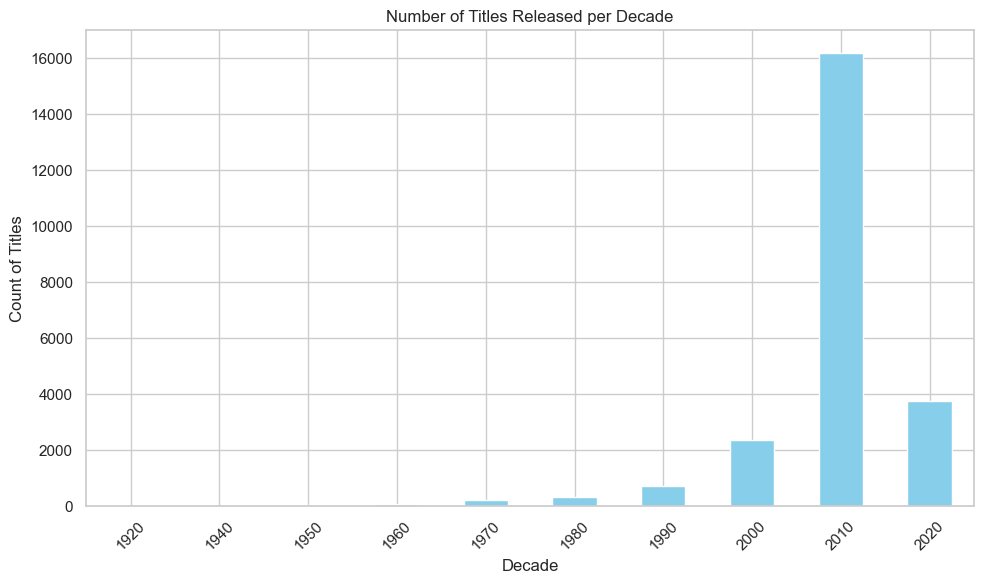

In [14]:
# Count of titles by decade
decade_counts = df_genres['release_decade'].value_counts().sort_index()

plt.figure(figsize=(10,6))
decade_counts.plot(kind='bar', color='skyblue')
plt.title('Number of Titles Released per Decade')
plt.xlabel('Decade')
plt.ylabel('Count of Titles')
plt.xticks(rotation=45)
plt.tight_layout()
savefig("chart5_titles_per_decade.png")
plt.show()

### Bar Chart of Top Directors (Top 15)

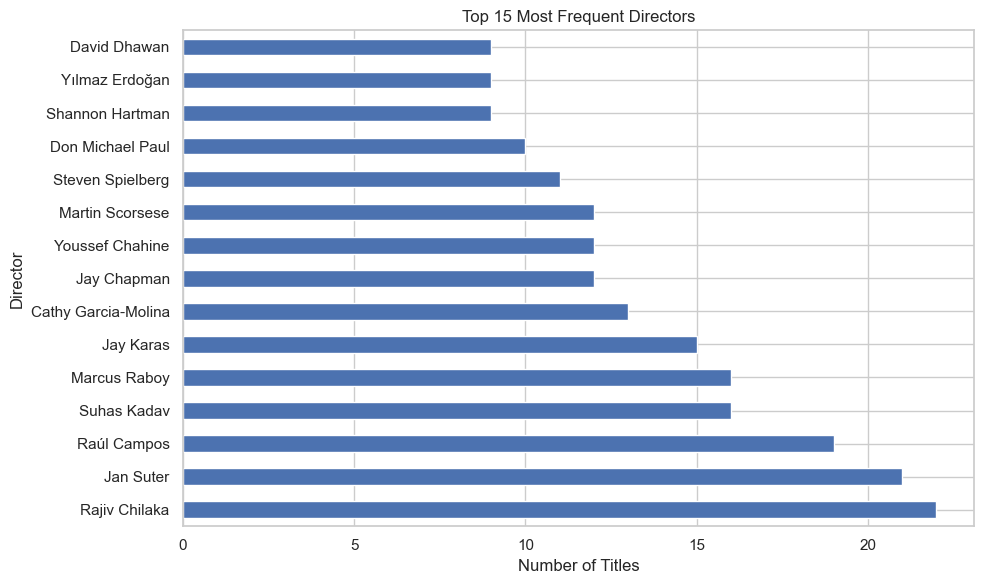

In [15]:
# Clean directors column and explode
df_directors = df.copy()
df_directors['director'] = df_directors['director'].fillna('').str.split(',')
df_directors = df_directors.explode('director')
df_directors['director'] = df_directors['director'].str.strip()
df_directors = df_directors[df_directors['director'] != '']

# Get top directors
top_directors = df_directors['director'].value_counts().nlargest(15)

plt.figure(figsize=(10,6))
top_directors.plot(kind='barh')
plt.title('Top 15 Most Frequent Directors')
plt.xlabel('Number of Titles')
plt.ylabel('Director')
plt.tight_layout()
savefig("chart6_top_directors.png")
plt.show()

### Bar Chart of Movies vs TV Shows by Year Added

<Figure size 1200x600 with 0 Axes>

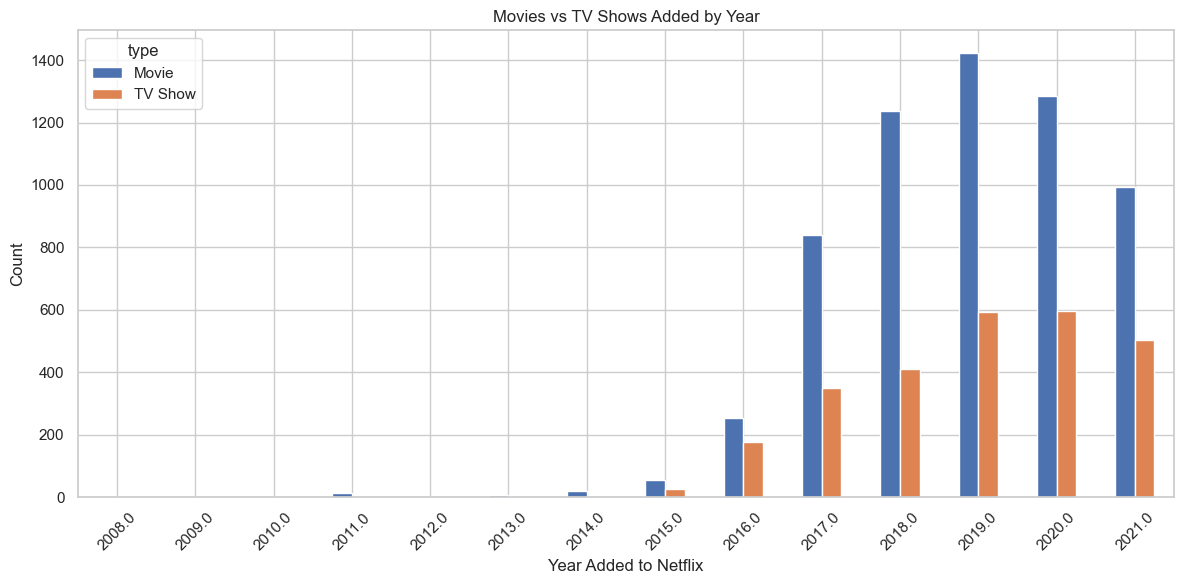

In [16]:
# Extract year content was added
df_year = df.copy()
df_year['year_added'] = df_year['date_added'].dt.year

# Drop missing years
df_year = df_year.dropna(subset=['year_added'])

# Count per type per year
year_type_counts = df_year.groupby(['year_added', 'type']).size().unstack(fill_value=0)

plt.figure(figsize=(12,6))
year_type_counts.plot(kind='bar', figsize=(12,6))
plt.title('Movies vs TV Shows Added by Year')
plt.xlabel('Year Added to Netflix')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
savefig("chart7_titles_added_by_year.png")
plt.show()

### Clustered (Grouped) bar chart: Genre vs Rating (Top N)

Saved chart5_grouped_genre_rating.png


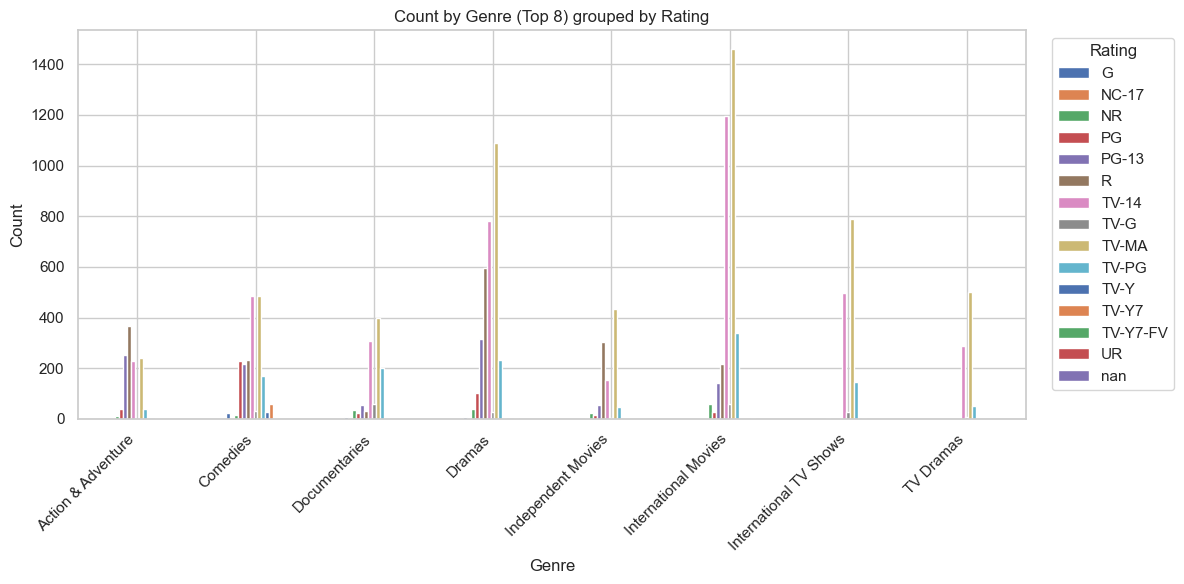

In [7]:
# We'll restrict to top 8 genres for readability
top8 = df_genres['listed_in'].value_counts().nlargest(8).index
cg = df_genres[df_genres['listed_in'].isin(top8)].groupby(['listed_in','rating']).size().unstack(fill_value=0)

# plot grouped bars
ax = cg.plot(kind='bar', figsize=(12,6))
plt.title('Count by Genre (Top 8) grouped by Rating')
plt.ylabel('Count')
plt.xlabel('Genre')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Rating', bbox_to_anchor=(1.02,1))
savefig("chart8_grouped_genre_rating.png")
plt.show()

### Diverging bar chart — Deviation from mean by Genre

Saved chart6_diverging_genre_dev.png


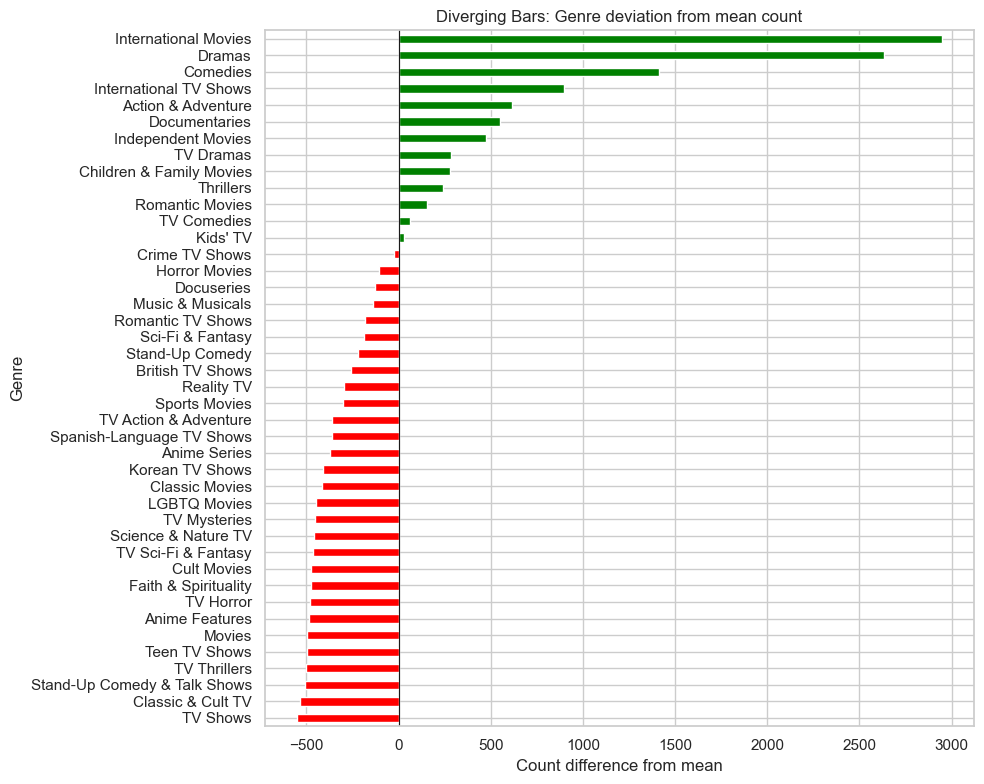

In [12]:
# Calculate deviation
genre_counts = df_genres['listed_in'].value_counts()
mean_val = genre_counts.mean()
dev = (genre_counts - mean_val).sort_values()

plt.figure(figsize=(10,8))
colors = ['red' if x < 0 else 'green' for x in dev]
dev.plot.barh(color=colors)
plt.axvline(0, color='k', linewidth=0.8)
plt.title('Diverging Bars: Genre deviation from mean count')
plt.xlabel('Count difference from mean')
plt.ylabel('Genre')
savefig("chart9_diverging_genre_dev.png")
plt.show()

### Outlier hypothesis and boxplot validation (use duration_min)

Saved boxplot_durations.png


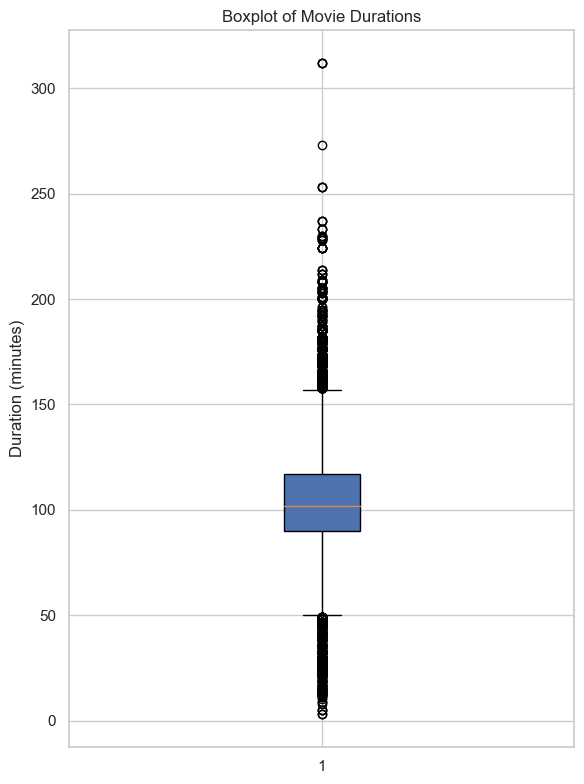

Outlier count: 993


In [13]:
# focus on movies with numeric duration
movies = df_genres[df_genres['is_movie'] & df_genres['duration_min'].notna()]

plt.figure(figsize=(6,8))
plt.boxplot(movies['duration_min'], vert=True, patch_artist=True)
plt.ylabel('Duration (minutes)')
plt.title('Boxplot of Movie Durations')
savefig("boxplot_durations.png")
plt.show()

# Compute IQR-based outliers and list titles
Q1 = movies['duration_min'].quantile(0.25)
Q3 = movies['duration_min'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = movies[(movies['duration_min'] < lower) | (movies['duration_min'] > upper)]
print("Outlier count:", outliers.shape[0])
outliers[['title','duration','duration_min','release_year','type']].drop_duplicates().head(50)
# Save outliers table for report
outliers[['title','duration','duration_min','release_year','type']].drop_duplicates().to_csv("duration_outliers.csv", index=False)